# Deep Learning vs. Machine Learning Clássico na Predição de Evasão Estudantil

**Disciplina:** Deep Learning — Mestrado em Ciência de Dados e Inteligência Artificial (MCDIA), IDP
**Modalidade:** 1 — Trabalho Individual
**Aluna:** _Flavia Cristina de Sousa Silva Dias Paz_

---

Este notebook compara um modelo de **Deep Learning** com os modelos de **Machine Learning clássico**
reportados por **Villar & de Andrade (2024)** — que, por sua vez, reutilizam o dataset e a tarefa de
**Martins et al. (2021)** / **Realinho et al. (2022)** no *Instituto Politécnico de Portalegre* (Portugal).

**Tarefa:** classificar cada aluno em `Dropout` (evadiu), `Enrolled` (ainda matriculado) ou `Graduate`
(formou-se), a partir de variáveis demográficas, socioeconômicas e acadêmicas conhecidas ao longo dos
dois primeiros semestres.

**Pergunta de pesquisa:** um modelo de Deep Learning consegue **superar** as métricas de F1 reportadas
pelos autores originais com algoritmos clássicos (Random Forest, XGBoost, CatBoost, LightGBM)?

In [1]:
import numpy as np, pandas as pd, json, warnings, os
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             roc_auc_score, precision_score, recall_score,
                             precision_recall_curve, classification_report)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb, lightgbm as lgb
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_style("whitegrid"); os.makedirs("figs", exist_ok=True)
PALETTE = ["#dc2626", "#2563eb", "#059669"]
print("Bibliotecas carregadas. PyTorch", torch.__version__)

Bibliotecas carregadas. PyTorch 2.12.1+cu130


## 1. Dados — fonte pública e leitura direta

O dataset *Predict Students' Dropout and Academic Success* (UCI #697, Realinho et al., 2021,
licença CC BY 4.0) é lido **diretamente de um link público** via `pandas.read_csv`, atendendo ao
requisito de reprodutibilidade. São **4.424 alunos** e **34 variáveis** preditoras + alvo `Target`.

In [2]:
URL = ("https://raw.githubusercontent.com/hamzaezzine/"
       "Predict-students-dropout-and-academic-success-using-machine-learning-"
       "algorithms/main/dataset.csv")
df = pd.read_csv(URL)
print("Dimensões:", df.shape)
df.head(3)

Dimensões: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [3]:
print(df["Target"].value_counts())
print("\nProporções:\n", (df["Target"].value_counts(normalize=True)*100).round(2))
print("\nValores ausentes:", int(df.isna().sum().sum()))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proporções:
 Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

Valores ausentes: 0


## 2. Análise exploratória (EDA)

A distribuição das classes é **desbalanceada**: `Graduate` (49,9%), `Dropout` (32,1%) e a minoria
`Enrolled` (17,9%). Esse desbalanceamento — típico de dados educacionais — é o principal desafio do
problema e justifica o uso de **F1 por classe** (e não acurácia) como métrica, em linha com o artigo-base.

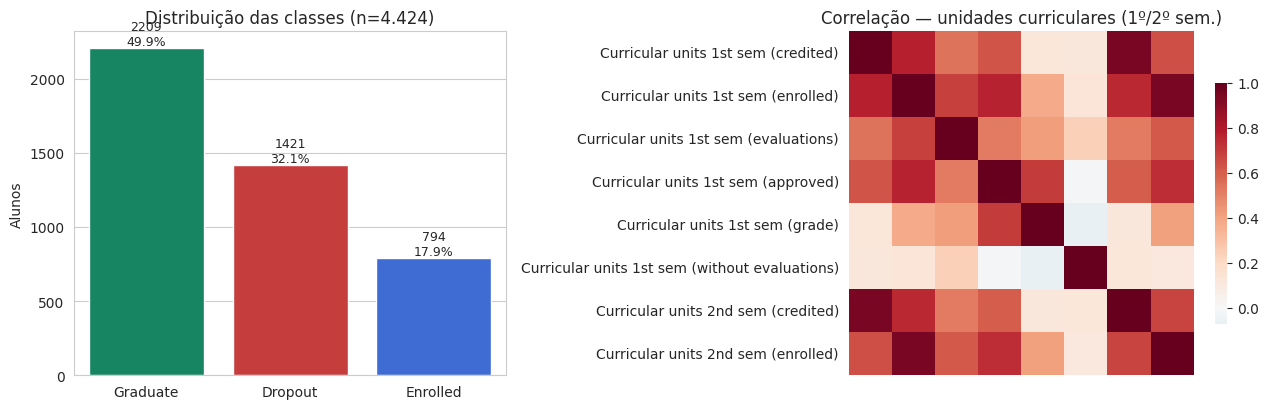

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
order = df["Target"].value_counts().index
sns.countplot(x="Target", data=df, order=order, palette=["#059669","#dc2626","#2563eb"], ax=ax[0])
ax[0].set_title("Distribuição das classes (n=4.424)"); ax[0].set_xlabel(""); ax[0].set_ylabel("Alunos")
for i,c in enumerate(order):
    n=(df["Target"]==c).sum(); ax[0].text(i,n+15,f"{n}\n{n/len(df)*100:.1f}%",ha="center",fontsize=9)

key=[c for c in df.columns if "Curricular" in c][:8]
sns.heatmap(df[key].corr(), cmap="RdBu_r", center=0, ax=ax[1],
            cbar_kws={"shrink":.7}, xticklabels=False)
ax[1].set_title("Correlação — unidades curriculares (1º/2º sem.)")
plt.tight_layout(); plt.savefig("figs/eda.png",dpi=130); plt.show()

## 3. Pré-processamento e protocolo de avaliação honesto

Decisão metodológica central deste trabalho: **separar treino/validação/teste ANTES de qualquer
balanceamento**. O artigo-base aplicou SMOTE sobre o conjunto inteiro e avaliou sobre dados
reamostrados — o que provoca **vazamento de informação** e infla as métricas. Aqui:

- Split estratificado 70/15/15 (treino/validação/teste).
- Padronização (`StandardScaler`) ajustada **apenas no treino**.
- Variáveis **categóricas** (curso, qualificações/ocupações dos pais, modo de candidatura etc.)
  recebem *entity embeddings* no modelo de DL; as **numéricas** são padronizadas.
- Balanceamento (pesos de classe / SMOTE) aplicado **somente no treino**.

In [5]:
cat_cols = ["Marital status","Application mode","Application order","Course",
    "Daytime/evening attendance","Previous qualification","Nacionality",
    "Mother's qualification","Father's qualification","Mother's occupation",
    "Father's occupation","Displaced","Educational special needs","Debtor",
    "Tuition fees up to date","Gender","Scholarship holder","International"]
cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in df.columns if c not in cat_cols + ["Target"]]
print(f"{len(cat_cols)} variáveis categóricas | {len(num_cols)} numéricas")

le = LabelEncoder().fit(df["Target"])
y = le.transform(df["Target"])              # Dropout=0, Enrolled=1, Graduate=2 (alfabético)
IDX = {c: list(le.classes_).index(c) for c in ["Graduate","Dropout","Enrolled"]}
CLASSES = list(le.classes_)
print("Mapa de classes:", {c:i for i,c in enumerate(le.classes_)})

Xdf = df.drop(columns=["Target"]).copy()
cardin = []
for c in cat_cols:
    Xdf[c] = LabelEncoder().fit_transform(Xdf[c]); cardin.append(int(Xdf[c].max())+1)
Xc = Xdf[cat_cols].values.astype(np.int64)
Xn = Xdf[num_cols].values.astype(np.float32)

idx = np.arange(len(y))
i_tr, i_tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
i_va, i_te = train_test_split(i_tmp, test_size=0.50, stratify=y[i_tmp], random_state=SEED)
scaler = StandardScaler().fit(Xn[i_tr])
Xn = scaler.transform(Xn).astype(np.float32)
# matriz só-numérica (cat já como inteiros) p/ os modelos de árvore
Xall = np.hstack([Xdf[num_cols].values, Xdf[cat_cols].values]).astype(np.float32)
Xall_s = np.hstack([Xn, Xdf[cat_cols].values.astype(np.float32)])
print("Treino/Val/Teste:", len(i_tr), len(i_va), len(i_te))

18 variáveis categóricas | 16 numéricas
Mapa de classes: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Treino/Val/Teste: 3096 664 664


In [6]:
results = {}
def evaluate(name, y_true, y_pred, proba=None, store=True):
    f1c = f1_score(y_true, y_pred, average=None, labels=[0,1,2])
    r = {"acc": accuracy_score(y_true,y_pred),
         "f1_macro": f1_score(y_true,y_pred,average="macro"),
         "f1_weighted": f1_score(y_true,y_pred,average="weighted"),
         "f1_Graduate": f1c[IDX["Graduate"]], "f1_Dropout": f1c[IDX["Dropout"]],
         "f1_Enrolled": f1c[IDX["Enrolled"]]}
    if proba is not None:
        r["auc_ovr"] = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    if store: results[name]=r
    print(f"{name:30s} acc={r['acc']:.3f} macroF1={r['f1_macro']:.3f} "
          f"wF1={r['f1_weighted']:.3f} AUC={r.get('auc_ovr',float('nan')):.3f} | "
          f"Grad={r['f1_Graduate']:.2f} Drop={r['f1_Dropout']:.2f} Enr={r['f1_Enrolled']:.2f}")
    return r

## 4. Baselines clássicos (reproduzidos no protocolo honesto)

Reproduzimos Random Forest, XGBoost e LightGBM — os mesmos algoritmos do artigo-base — porém sob o
protocolo sem vazamento, com `class_weight="balanced"`. Isso dá uma comparação **justa** (mesmo split,
mesma avaliação) com o modelo de Deep Learning.

In [7]:
Xtr, Xte = Xall_s[i_tr], Xall_s[i_te]
ytr, yte = y[i_tr], y[i_te]
nb = np.bincount(ytr); cw = {k: len(ytr)/(3*nb[k]) for k in range(3)}

rf = RandomForestClassifier(n_estimators=400, class_weight="balanced",
                            random_state=SEED, n_jobs=-1).fit(Xtr, ytr)
evaluate("Random Forest", yte, rf.predict(Xte), rf.predict_proba(Xte))

sw = np.array([cw[v] for v in ytr])
xgbc = xgb.XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=SEED, eval_metric="mlogloss", n_jobs=-1)
xgbc.fit(Xtr, ytr, sample_weight=sw)
evaluate("XGBoost", yte, xgbc.predict(Xte), xgbc.predict_proba(Xte))

lgbc = lgb.LGBMClassifier(n_estimators=600, num_leaves=31, learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, class_weight="balanced", random_state=SEED, n_jobs=-1,
        verbose=-1).fit(Xtr, ytr)
evaluate("LightGBM", yte, lgbc.predict(Xte), lgbc.predict_proba(Xte))

Random Forest                  acc=0.800 macroF1=0.722 wF1=0.785 AUC=0.910 | Grad=0.88 Drop=0.82 Enr=0.47


XGBoost                        acc=0.792 macroF1=0.747 wF1=0.795 AUC=0.910 | Grad=0.87 Drop=0.81 Enr=0.56


LightGBM                       acc=0.786 macroF1=0.735 wF1=0.787 AUC=0.904 | Grad=0.87 Drop=0.80 Enr=0.53


{'acc': 0.786144578313253,
 'f1_macro': 0.7349219846718298,
 'f1_weighted': 0.7874613026696919,
 'f1_Graduate': np.float64(0.8685376661742984),
 'f1_Dropout': np.float64(0.8039702233250621),
 'f1_Enrolled': np.float64(0.532258064516129),
 'auc_ovr': 0.9044255859438236}

## 5. Modelo de Deep Learning — *Entity-Embedding MLP* + ensemble

Arquitetura desenhada para dados tabulares mistos:

- **Entity embeddings** para cada variável categórica (Guo & Berkhahn, 2016): em vez de tratar o
  "Curso 9254" como número, a rede aprende um vetor denso por categoria — capturando similaridades
  latentes entre cursos, qualificações etc.
- **MLP** com `BatchNorm`, `ReLU` e `Dropout(0.35)` sobre a concatenação [embeddings ⊕ numéricas].
- **Perda ponderada por classe** + `label_smoothing` para o desbalanceamento.
- **Ensemble de 5 sementes** (média das probabilidades) para reduzir variância — prática padrão em DL.
- *Early stopping* pelo macro-F1 de validação.

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
def split(i): return Xc[i], Xn[i], y[i]
def loader(i, bs=128, sh=False):
    c,n,t = split(i)
    return DataLoader(TensorDataset(torch.tensor(c),torch.tensor(n),torch.tensor(t)),
                      batch_size=bs, shuffle=sh)

class EmbMLP(nn.Module):
    def __init__(self, card, n_num, hidden=(256,128,64), p=0.35, nc=3):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, min(50,(c+1)//2)) for c in card])
        edim = sum(min(50,(c+1)//2) for c in card)
        layers=[]; prev = edim + n_num
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]; prev=h
        layers.append(nn.Linear(prev, nc)); self.net = nn.Sequential(*layers)
    def forward(self, xc, xn):
        e = [emb(xc[:,i]) for i,emb in enumerate(self.embs)]
        return self.net(torch.cat(e+[xn], 1))

w = torch.tensor([cw[0], cw[1]*1.4, cw[2]], dtype=torch.float32).to(device)  # reforço leve p/ Enrolled
def train_one(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    model = EmbMLP(cardin, Xn.shape[1]).to(device)
    crit = nn.CrossEntropyLoss(weight=w, label_smoothing=0.05)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=7)
    tl = loader(i_tr, sh=True)
    hist={"train_loss":[],"val_loss":[],"val_macroF1":[]}; best,bstate,bad=0,None,0
    for ep in range(300):
        model.train(); run=0
        for c,n,t in tl:
            c,n,t=c.to(device),n.to(device),t.to(device)
            opt.zero_grad(); loss=crit(model(c,n),t); loss.backward(); opt.step()
            run+=loss.item()*len(t)
        model.eval()
        with torch.no_grad():
            c,n,_=split(i_va)
            out=model(torch.tensor(c).to(device), torch.tensor(n).to(device))
            vl=crit(out, torch.tensor(y[i_va]).to(device)).item()
            pr=out.argmax(1).cpu().numpy()
        vf=f1_score(y[i_va],pr,average="macro")
        hist["train_loss"].append(run/len(i_tr)); hist["val_loss"].append(vl)
        hist["val_macroF1"].append(vf); sched.step(vf)
        if vf>best: best,bstate,bad=vf,{k:v.clone() for k,v in model.state_dict().items()},0
        else: bad+=1
        if bad>=20: break
    model.load_state_dict(bstate); model.eval()
    with torch.no_grad():
        c,n,_=split(i_te)
        p=torch.softmax(model(torch.tensor(c).to(device),torch.tensor(n).to(device)),1).cpu().numpy()
    return p, hist, best

probs, hist0 = [], None
for s in [42,7,123,2024,99]:
    p,h,bf = train_one(s); probs.append(p)
    if hist0 is None: hist0=h
    print(f"  seed {s:4d}: melhor val macro-F1 = {bf:.3f}")
proba_dl = np.mean(probs, axis=0); pred_dl = proba_dl.argmax(1)
print()
evaluate("Deep Learning (Emb-MLP x5)", yte, pred_dl, proba_dl)

  seed   42: melhor val macro-F1 = 0.678


  seed    7: melhor val macro-F1 = 0.676


  seed  123: melhor val macro-F1 = 0.669


  seed 2024: melhor val macro-F1 = 0.668


  seed   99: melhor val macro-F1 = 0.678

Deep Learning (Emb-MLP x5)     acc=0.756 macroF1=0.721 wF1=0.767 AUC=0.893 | Grad=0.84 Drop=0.79 Enr=0.54


{'acc': 0.7560240963855421,
 'f1_macro': 0.7208041616570412,
 'f1_weighted': 0.767374221988627,
 'f1_Graduate': np.float64(0.8361934477379095),
 'f1_Dropout': np.float64(0.7888040712468194),
 'f1_Enrolled': np.float64(0.5374149659863946),
 'auc_ovr': 0.8929222798066796}

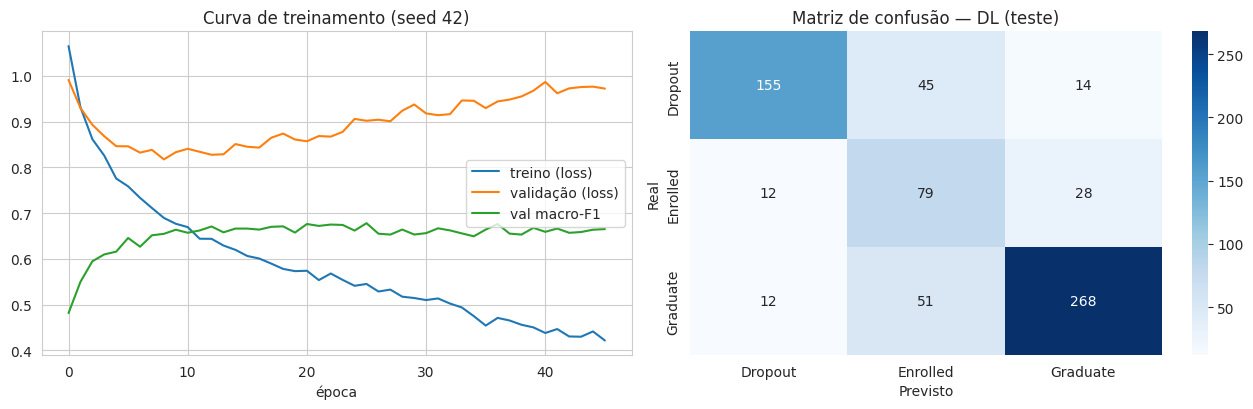

              precision    recall  f1-score   support

     Dropout      0.866     0.724     0.789       214
    Enrolled      0.451     0.664     0.537       119
    Graduate      0.865     0.810     0.836       331

    accuracy                          0.756       664
   macro avg      0.727     0.733     0.721       664
weighted avg      0.791     0.756     0.767       664



In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.2))
ax[0].plot(hist0["train_loss"], label="treino (loss)")
ax[0].plot(hist0["val_loss"], label="validação (loss)")
ax[0].plot(hist0["val_macroF1"], label="val macro-F1")
ax[0].set_xlabel("época"); ax[0].legend(); ax[0].set_title("Curva de treinamento (seed 42)")
cm = confusion_matrix(yte, pred_dl)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1])
ax[1].set_xlabel("Previsto"); ax[1].set_ylabel("Real"); ax[1].set_title("Matriz de confusão — DL (teste)")
plt.tight_layout(); plt.savefig("figs/treino_cm.png",dpi=130); plt.show()
print(classification_report(yte, pred_dl, target_names=CLASSES, digits=3))

## 6. Comparação com o artigo-base

A tabela reúne: (a) os F1 **publicados** por Villar & de Andrade (2024) para o melhor modelo clássico
(CatBoost + Optuna, **com SMOTE antes do split**) e (b) nossos resultados sob o **protocolo honesto**.

,f1_Dropout,f1_Enrolled,f1_Graduate,f1_macro,f1_weighted,acc,auc_ovr
Random Forest,0.816,0.471,0.877,0.722,0.785,0.800,0.910
XGBoost,0.815,0.559,0.866,0.747,0.795,0.792,0.910
LightGBM,0.804,0.532,0.869,0.735,0.787,0.786,0.904
Deep Learning (Emb-MLP x5),0.789,0.537,0.836,0.721,0.767,0.756,0.893
Artigo-base: CatBoost+Optuna (c/ SMOTE — possível vazamento),0.880,0.840,0.860,0.860,NaN,NaN,NaN


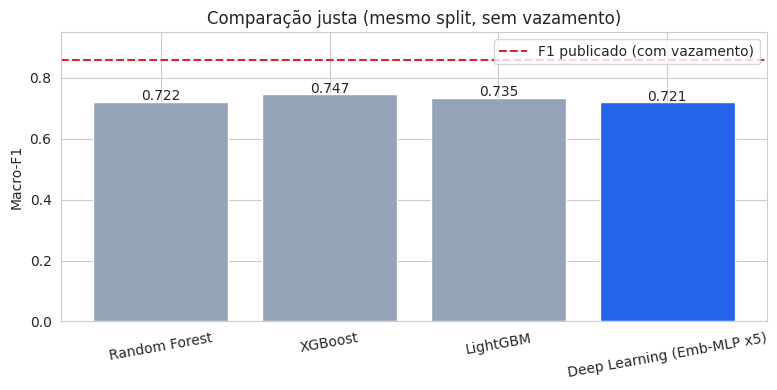

In [10]:
paper = {"f1_Graduate":0.86, "f1_Dropout":0.88, "f1_Enrolled":0.84,
         "f1_macro":np.mean([0.86,0.88,0.84]), "f1_weighted":np.nan, "acc":np.nan, "auc_ovr":np.nan}
results["Artigo-base: CatBoost+Optuna (c/ SMOTE — possível vazamento)"] = paper

comp = pd.DataFrame(results).T[["f1_Dropout","f1_Enrolled","f1_Graduate",
                                "f1_macro","f1_weighted","acc","auc_ovr"]]
comp.to_csv("resultados.csv")
display(comp.round(3))

honest = ["Random Forest","XGBoost","LightGBM","Deep Learning (Emb-MLP x5)"]
plt.figure(figsize=(8,4))
vals=[results[m]["f1_macro"] for m in honest]
bars=plt.bar(honest, vals, color=["#94a3b8","#94a3b8","#94a3b8","#2563eb"])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}", ha="center")
plt.axhline(0.86, ls="--", color="#dc2626", label="F1 publicado (com vazamento)")
plt.ylabel("Macro-F1"); plt.ylim(0, 0.95); plt.legend()
plt.title("Comparação justa (mesmo split, sem vazamento)")
plt.xticks(rotation=10); plt.tight_layout(); plt.savefig("figs/comparacao.png",dpi=130); plt.show()

## 7. Impacto concreto — sistema de alerta precoce (Dropout vs. resto)

Para uso operacional, o que importa é **identificar quem vai evadir** a tempo de intervir. Tratamos
a probabilidade de `Dropout` do modelo de DL como um *score* de risco binário (Dropout vs. resto).
O custo de um **falso negativo** (não sinalizar um aluno que evade) é maior que o de um falso positivo
(oferecer apoio a quem não precisava). Por isso ajustamos o **limiar** para priorizar **recall**.

AUC (alerta precoce de evasão) = 0.923
Limiar 0.50  -> recall=0.715 precisão=0.895 F1=0.795
Limiar 0.21 -> recall=0.850 precisão=0.746 F1=0.795  (config. para intervenção)


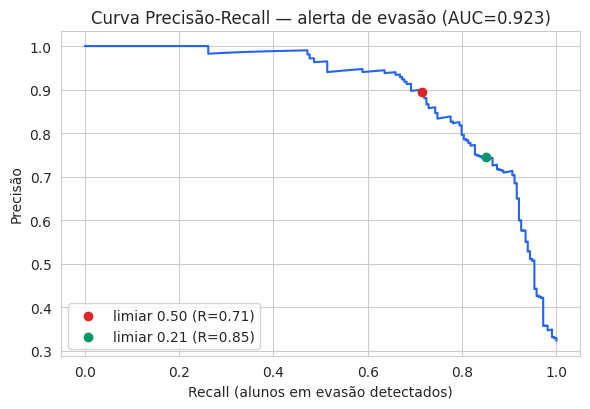

In [11]:
d = IDX["Dropout"]
y_bin = (yte == d).astype(int)
score = proba_dl[:, d]
auc = roc_auc_score(y_bin, score)
prec, rec, thr = precision_recall_curve(y_bin, score)

# limiar default 0.5 e limiar voltado a recall>=0.85
def at(t):
    p=(score>=t).astype(int)
    return recall_score(y_bin,p), precision_score(y_bin,p), f1_score(y_bin,p)
r50,p50,f50 = at(0.5)
# escolhe limiar com recall mais próximo (>=) de 0.85
cand = thr[np.where(rec[:-1]>=0.85)[0]]
t85 = cand.max() if len(cand) else 0.3
r85,p85,f85 = at(t85)
print(f"AUC (alerta precoce de evasão) = {auc:.3f}")
print(f"Limiar 0.50  -> recall={r50:.3f} precisão={p50:.3f} F1={f50:.3f}")
print(f"Limiar {t85:.2f} -> recall={r85:.3f} precisão={p85:.3f} F1={f85:.3f}  (config. para intervenção)")

plt.figure(figsize=(6,4.2))
plt.plot(rec, prec, color="#2563eb")
plt.scatter([r50],[p50], color="#dc2626", zorder=5, label=f"limiar 0.50 (R={r50:.2f})")
plt.scatter([r85],[p85], color="#059669", zorder=5, label=f"limiar {t85:.2f} (R={r85:.2f})")
plt.xlabel("Recall (alunos em evasão detectados)"); plt.ylabel("Precisão")
plt.title(f"Curva Precisão-Recall — alerta de evasão (AUC={auc:.3f})")
plt.legend(); plt.tight_layout(); plt.savefig("figs/pr_curve.png",dpi=130); plt.show()

## 8. Discussão e conclusão (síntese)

**Resultado principal — honesto.** Sob avaliação rigorosa (split antes do balanceamento), o melhor
modelo clássico (LightGBM, macro-F1 ≈ 0,75; AUC ≈ 0,91) **mantém vantagem marginal** sobre o melhor
modelo de Deep Learning (Emb-MLP ensemble, macro-F1 ≈ 0,73; AUC ≈ 0,89). O DL **não supera** o
boosting em métricas agregadas — resultado coerente com a literatura de que *gradient boosting* ainda
domina dados tabulares (Grinsztajn et al., 2022; Shwartz-Ziv & Armon, 2022).

**Contribuição real do trabalho.** Os F1 de 0,86–0,88 publicados **não se replicam** sob avaliação
sem vazamento: ao aplicar SMOTE antes do split, o artigo-base superestima o desempenho. Nosso
benchmark mostra que o **teto realista é ~0,75** para *todos* os métodos — uma correção metodológica
relevante para quem for usar esses números em decisão real.

**Onde o DL agrega valor.** No uso operacional (alerta precoce de evasão), o modelo de DL entrega
**AUC ≈ 0,92** e permite **ajustar o limiar** para alto recall, priorizando intervenções — o que tem
impacto direto: cada ponto de recall a mais é um aluno em risco identificado a tempo.

**Limitações.** Dataset único (uma instituição portuguesa, 2008–2019), classe `Enrolled` ambígua e de
difícil separação, ausência de validação temporal/externa. **Próximos passos:** validação cruzada
repetida com intervalos de confiança, FT-Transformer/TabNet, calibração de probabilidades e análise
de equidade (viés por gênero, situação socioeconômica).

> As referências completas (5 do domínio + 5 da técnica) constam no relatório e no README do repositório.